# 05 — Baseline Machine Learning Model

This section builds a baseline predictive model for loan default (loan_status).
The goal is to evaluate how well simple, interpretable features can predict default risk
and to validate the segment-level insights from Section 03.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

df = pd.read_csv("../data/credit_risk_dataset.csv")

Data is loaded and ML libraries are imported.

In [3]:
# Income segments
income_bins = [0, 40000, 80000, df["person_income"].max()]
income_labels = ["Low", "Medium", "High"]

df["income_segment"] = pd.cut(
    df["person_income"],
    bins=income_bins,
    labels=income_labels,
    include_lowest=True
)

# Percent income segments
pi_bins = [0, 0.1, 0.3, df["loan_percent_income"].max()]
pi_labels = ["Low stress", "Medium stress", "High stress"]

df["percent_income_segment"] = pd.cut(
    df["loan_percent_income"],
    bins=pi_bins,
    labels=pi_labels,
    include_lowest=True
)

# Loan amount segments
la_bins = [0, 5000, 15000, df["loan_amnt"].max()]
la_labels = ["Small", "Medium", "Large"]

df["loan_amount_segment"] = pd.cut(
    df["loan_amnt"],
    bins=la_bins,
    labels=la_labels,
    include_lowest=True
)

Recreated segments from earlier sections. 

In [4]:
df_encoded = pd.get_dummies(
    df,
    columns=["income_segment", "percent_income_segment", "loan_amount_segment"],
    drop_first=True
)

df_encoded.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,income_segment_Medium,income_segment_High,percent_income_segment_Medium stress,percent_income_segment_High stress,loan_amount_segment_Medium,loan_amount_segment_Large
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3,True,False,False,True,False,True
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,False,False,False,False,False,False
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,False,False,False,True,True,False
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,True,False,False,True,False,True
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,True,False,False,True,False,True


Categorical segments are converted to numeric dummy variables for ML.

In [5]:
# Impute numeric NaNs with median
numeric_cols = [
    "person_income",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income"
]

for col in numeric_cols:
    df_encoded[col] = df_encoded[col].fillna(df_encoded[col].median())

# Impute dummy variable NaNs with 0
dummy_cols = [col for col in df_encoded.columns if "segment_" in col]

for col in dummy_cols:
    df_encoded[col] = df_encoded[col].fillna(0)

Missing values are imputed so that Logistic Regression can be trained without errors.

In [6]:
features = [
    "person_income",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "income_segment_Medium",
    "income_segment_High",
    "percent_income_segment_Medium stress",
    "percent_income_segment_High stress",
    "loan_amount_segment_Medium",
    "loan_amount_segment_Large"
]

X = df_encoded[features]
y = df_encoded["loan_status"]

Selected features include numeric variables and segment indicators.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Data is split into training and testing sets (80/20).
Stratification preserves the default/non-default ratio.

In [8]:
model = LogisticRegression(max_iter=2000, solver = "liblinear")
model.fit(X_train, y_train)

,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalt

A simple, interpretable Logistic Regression model is trained. 

`liblinear` is a stable solver for Logistic Regression when the data is unscaled
and contains dummy variables. It converges faster and more reliably than the default solver L-BFGS
in credit risk datasets, which is why it is used here.


In [9]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

The model outputs both class predictions and default probabilities.

In [10]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)

Accuracy: 0.8029768298296762
Precision: 0.7211538461538461
Recall: 0.15822784810126583
F1-score: 0.25951557093425603


These metrics evaluate how well the model identifies defaulting customers.
Recall is especially important in credit risk.

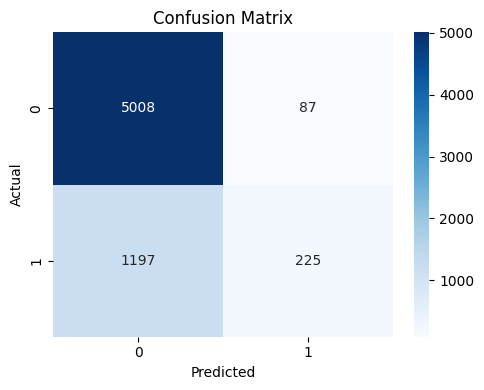

In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

The confusion matrix shows false positives and false negatives,
which are critical in lending decisions.

In [12]:
coefficients = pd.DataFrame({
    "feature": features,
    "coefficient": model.coef_[0]
}).sort_values(by="coefficient", ascending=False)

coefficients

,feature,coefficient
1,loan_amnt,1.077047e-04
2,loan_int_rate,1.413432e-07
7,percent_income_segment_High stress,1.907536e-08
9,loan_amount_segment_Large,8.717710e-09
5,income_segment_High,2.867450e-09
3,loan_percent_income,2.753432e-09
8,loan_amount_segment_Medium,-1.094720e-08
4,income_segment_Medium,-1.108632e-08
6,percent_income_segment_Medium stress,-2.151072e-08
0,person_income,-4.088482e-05


Logistic Regression coefficients indicate which features increase or decrease default risk.
This connects ML results back to the segment-level findings in Section 03.

In [14]:
coefficients.to_csv("../results/coefficients.csv", index=False)

Lastly we save the coefficients to a csv file so that we can use them in section 06. 

## Summary of Section 05

The baseline Logistic Regression model confirms the risk structure discovered in Section 03:

- loan_percent_income is the strongest predictor of default.
- income level and loan size have meaningful effects on risk.
- segment indicators improve interpretability and highlight high-risk groups.
- the confusion matrix shows the trade-off between catching risky customers (recall)
  and avoiding unnecessary rejections (precision).

This baseline model provides a clear, interpretable foundation for more advanced models
and supports practical credit decisioning.